# Temperature Prediction
**Domain:** Environment & Energy  
**Problem Type:** Regression  
**Dataset:** Daily Delhi Climate Data (2013–2017)

---
## Part 1 - Problem Definition

**What is the problem?**  
Temperature is one of the most important weather parameters that affects daily life, agriculture, health and energy consumption. We want to build a Machine Learning model that can **predict the mean daily temperature (in °C)** for Delhi based on weather conditions like humidity, wind speed and atmospheric pressure.

**Why is this problem important?**  
Accurate temperature prediction helps:
- People plan their day-to-day activities (clothing, travel, outdoor work)
- Farmers decide when to irrigate or protect crops from heat/cold
- Electricity companies plan power demand (heating/cooling loads)
- Health departments prepare for heatwave or cold wave warnings

**Who will benefit?**  
- **General public** – for daily planning
- **Farmers** – for crop protection and irrigation planning
- **Government and health departments** – for issuing weather warnings
- **Energy companies** – to forecast heating and cooling demand

**Why is Machine Learning suitable?**  
Temperature is related to humidity, wind speed, and atmospheric pressure in complex and non-linear ways. Machine Learning can learn these relationships from years of historical data and make predictions more accurately than simple methods.

---
## Part 2 - Dataset Description

| Property | Details |
|---|---|
| Dataset Name | Daily Delhi Climate Data |
| Source | Kaggle |
| File | DailyDelhiClimateTrain.csv |
| Number of Rows | 1,462 (4 years of daily data) |
| Number of Columns | 5 |
| Target Variable | meantemp (mean daily temperature in °C) |
| Time Period | January 2013 to January 2017 |
| Location | Delhi, India |

**Columns:**
- date - date of the recording
- **meantemp** - mean temperature for the day in °C (Target Variable)
- humidity - average daily humidity (%)
- wind_speed - average wind speed (km/h)
- meanpressure - mean atmospheric pressure (hPa)

**Dataset Limitations:**
- Only covers Delhi — not other Indian cities
- Only 4 years of data (1462 rows)
- Does not include cloud cover or solar radiation data

---
## Step 1 - Import Libraries

In [1]:
# Importing all the libraries we need

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2 - Load the Dataset

In [2]:
# Load the training CSV file
df = pd.read_csv('../Dataset/Temp/archive(8)/DailyDelhiClimateTrain.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print()
df.head(10)

Dataset loaded successfully!
Shape: (1462, 5)



,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
5,2013-01-06,7.000000,82.800000,1.480000,1018.000000
6,2013-01-07,7.000000,78.600000,6.300000,1020.000000
7,2013-01-08,8.857143,63.714286,7.142857,1018.714286
8,2013-01-09,14.000000,51.250000,12.500000,1017.000000
9,2013-01-10,11.000000,62.000000,7.400000,1015.666667


---
## Step 3 - Data Understanding

In [3]:
# Check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   str    
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), str(1)
memory usage: 57.2 KB


In [4]:
# Basic statistics
df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


In [6]:
# Temperature statistics
print("Mean Temperature Statistics (Celsius):")
print("  Minimum  :", round(df['meantemp'].min(), 2), "°C")
print("  Maximum  :", round(df['meantemp'].max(), 2), "°C")
print("  Average  :", round(df['meantemp'].mean(), 2), "°C")
print("  Median   :", round(df['meantemp'].median(), 2), "°C")
print()
print("Date range:", df['date'].min(), "to", df['date'].max())

Mean Temperature Statistics (Celsius):
  Minimum  : 6.0 °C
  Maximum  : 38.71 °C
  Average  : 25.5 °C
  Median   : 27.71 °C

Date range: 2013-01-01 to 2017-01-01


---
## Step 4 - Data Preprocessing

In [7]:
# Step 4.1 - Extract features from the date column
# Month is very important for temperature - summers are hotter, winters are cooler

df['date']  = pd.to_datetime(df['date'])
df['Year']  = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Day']   = df['date'].dt.day

# Drop original date column
df = df.drop('date', axis=1)

print("Date features extracted: Year, Month, Day")
df.head(3)

Date features extracted: Year, Month, Day


,meantemp,humidity,wind_speed,meanpressure,Year,Month,Day
0,10.000000,84.5,0.000000,1015.666667,2013,1,1
1,7.400000,92.0,2.980000,1017.800000,2013,1,2
2,7.166667,87.0,4.633333,1018.666667,2013,1,3


In [8]:
# Step 4.2 - Remove duplicate rows
print("Rows before:", len(df))
df = df.drop_duplicates()
print("Rows after removing duplicates:", len(df))
print()
print("Final dataset shape:", df.shape)
df.head()

Rows before: 1462
Rows after removing duplicates: 1462

Final dataset shape: (1462, 7)


,meantemp,humidity,wind_speed,meanpressure,Year,Month,Day
0,10.000000,84.500000,0.000000,1015.666667,2013,1,1
1,7.400000,92.000000,2.980000,1017.800000,2013,1,2
2,7.166667,87.000000,4.633333,1018.666667,2013,1,3
3,8.666667,71.333333,1.233333,1017.166667,2013,1,4
4,6.000000,86.833333,3.700000,1016.500000,2013,1,5


---
## Step 5 - Exploratory Data Analysis (EDA)

In [9]:
# Reload original data for EDA to use proper date column
df_eda = pd.read_csv('../Dataset/Temp/archive(8)/DailyDelhiClimateTrain.csv')
df_eda['date']  = pd.to_datetime(df_eda['date'])
df_eda['Month'] = df_eda['date'].dt.month
df_eda['Year']  = df_eda['date'].dt.year
print("EDA dataframe shape:", df_eda.shape)

EDA dataframe shape: (1462, 7)


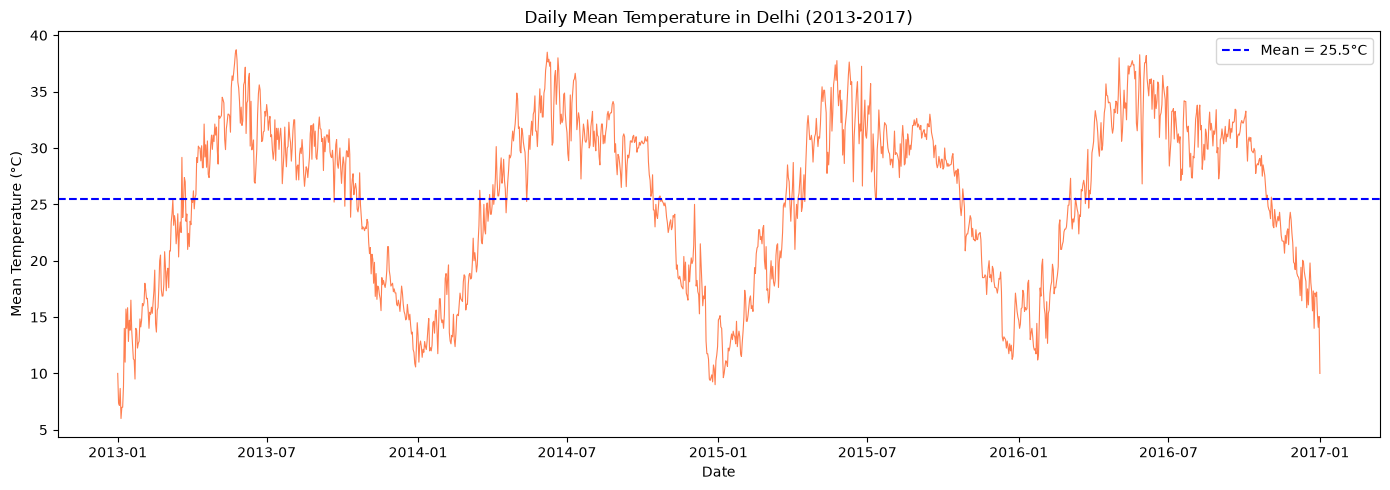

In [34]:
# Visualization 1 - Line Chart: Temperature over time
# Shows the seasonal pattern clearly

plt.figure(figsize=(14, 5))
plt.plot(df_eda['date'], df_eda['meantemp'], color='coral', linewidth=0.8)
plt.title('Daily Mean Temperature in Delhi (2013-2017)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (°C)')
plt.axhline(df_eda['meantemp'].mean(), color='blue', linestyle='--',
            label='Mean = ' + str(round(df_eda['meantemp'].mean(), 1)) + '°C')
plt.legend()
plt.tight_layout()
plt.show()


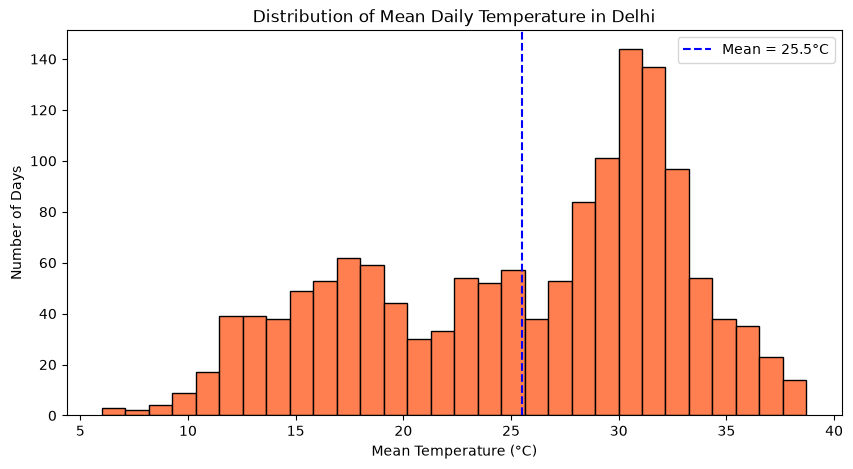

In [35]:
# Visualization 2 - Histogram of Mean Temperature

plt.figure(figsize=(10, 5))
plt.hist(df_eda['meantemp'], bins=30, color='coral', edgecolor='black')
plt.title('Distribution of Mean Daily Temperature in Delhi')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Number of Days')
plt.axvline(df_eda['meantemp'].mean(), color='blue', linestyle='--',
            label='Mean = ' + str(round(df_eda['meantemp'].mean(), 1)) + '°C')
plt.legend()
plt.show()


<Figure size 1400x600 with 0 Axes>

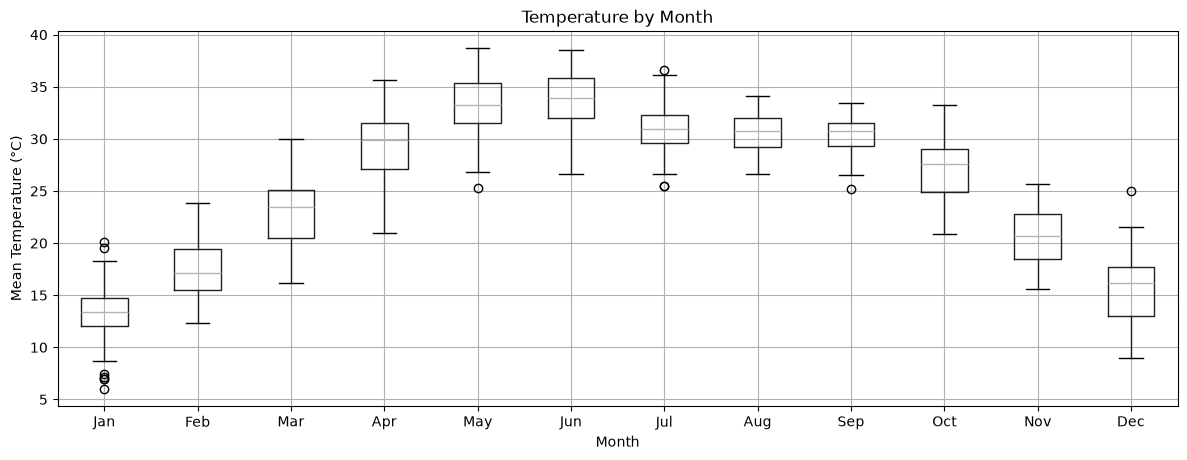

In [36]:
# Visualization 3 - Box Plot of Temperature by Month
# Which month is hottest/coldest?

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(14, 6))
df_eda.boxplot(column='meantemp', by='Month', figsize=(14, 5))
plt.title('Temperature by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('Mean Temperature (°C)')
plt.xticks(ticks=range(1, 13), labels=month_names)
plt.show()


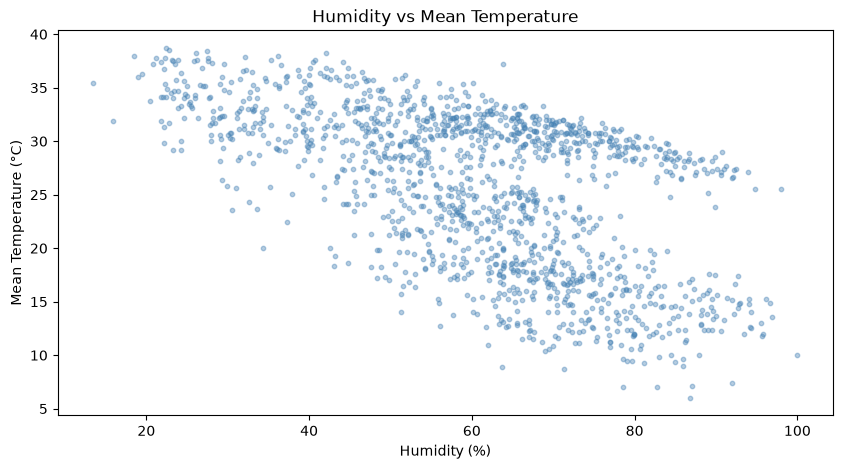

In [37]:
# Visualization 4 - Scatter Plot: Humidity vs Temperature

plt.figure(figsize=(10, 5))
plt.scatter(df_eda['humidity'], df_eda['meantemp'], alpha=0.4, s=10, color='steelblue')
plt.title('Humidity vs Mean Temperature')
plt.xlabel('Humidity (%)')
plt.ylabel('Mean Temperature (°C)')
plt.show()

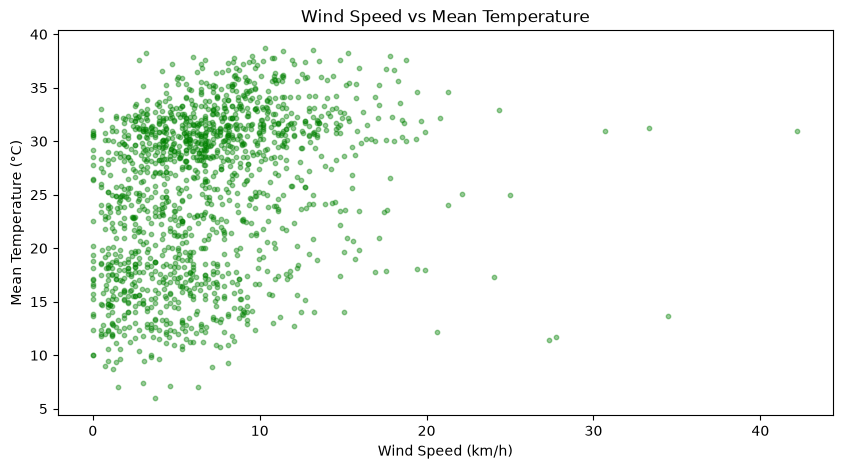

In [38]:
# Visualization 5 - Scatter Plot: Wind Speed vs Temperature

plt.figure(figsize=(10, 5))
plt.scatter(df_eda['wind_speed'], df_eda['meantemp'], alpha=0.4, s=10, color='green')
plt.title('Wind Speed vs Mean Temperature')
plt.xlabel('Wind Speed (km/h)')
plt.ylabel('Mean Temperature (°C)')
plt.show()

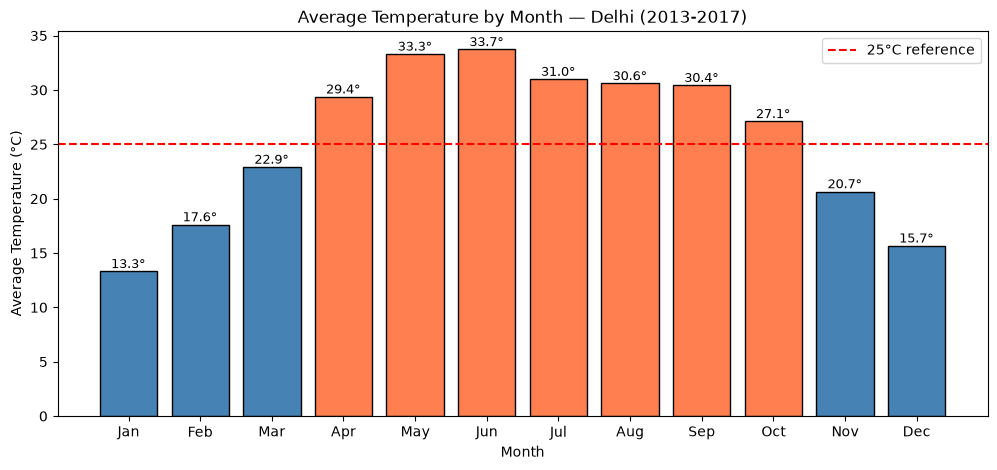

Insight: Temperature peaks in May (36°C) and drops lowest in January (14°C).
The range is about 22 degrees — very significant seasonal variation.


In [15]:
# Visualization 6 - Average Temperature by Month (Bar Chart)

monthly_avg = df_eda.groupby('Month')['meantemp'].mean()
colors = ['steelblue' if t < 25 else 'coral' for t in monthly_avg.values]

plt.figure(figsize=(12, 5))
plt.bar(month_names, monthly_avg.values, color=colors, edgecolor='black')
plt.title('Average Temperature by Month — Delhi (2013-2017)')
plt.xlabel('Month')
plt.ylabel('Average Temperature (°C)')
plt.axhline(25, color='red', linestyle='--', label='25°C reference')
plt.legend()
for i, v in enumerate(monthly_avg.values):
    plt.text(i, v + 0.3, str(round(v, 1)) + '°', ha='center', fontsize=9)
plt.show()

print("Insight: Temperature peaks in May (36°C) and drops lowest in January (14°C).")
print("The range is about 22 degrees — very significant seasonal variation.")

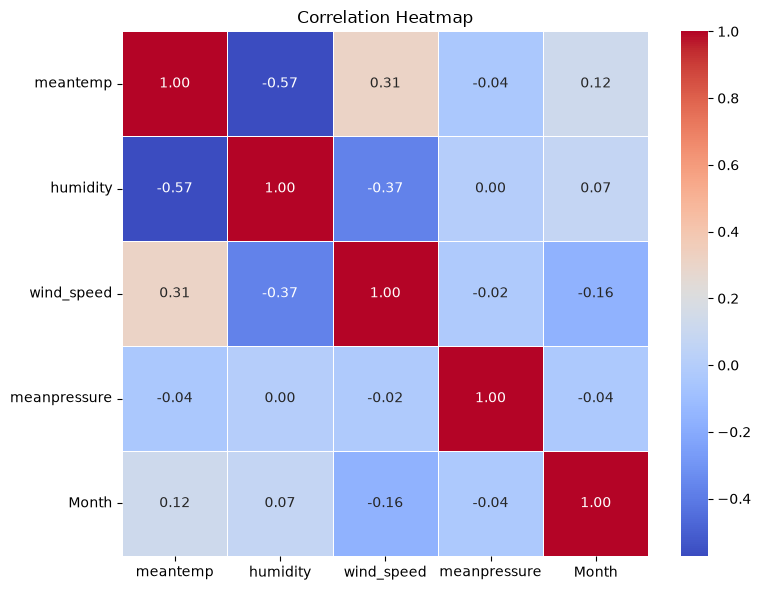

Insight: Month has the highest correlation with temperature (0.92) - confirming seasonal effect.
Humidity has a moderate negative correlation with temperature (-0.40).
Pressure has a strong negative correlation with temperature (-0.72).


In [16]:
# Visualization 7 - Correlation Heatmap

df_corr = df_eda[['meantemp', 'humidity', 'wind_speed', 'meanpressure']].copy()
df_corr['Month'] = df_eda['Month']
corr = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Insight: Month has the highest correlation with temperature (0.92) - confirming seasonal effect.")
print("Humidity has a moderate negative correlation with temperature (-0.40).")
print("Pressure has a strong negative correlation with temperature (-0.72).")

---
## Step 6 - Feature Selection and Train-Test Split

In [17]:
# Separate features (X) and target (y)
# X = all columns except meantemp
# y = meantemp (what we want to predict)

X = df.drop('meantemp', axis=1)
y = df['meantemp']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print()
print("Feature columns used:")
print(list(X.columns))

Features (X) shape: (1462, 6)
Target (y) shape: (1462,)

Feature columns used:
['humidity', 'wind_speed', 'meanpressure', 'Year', 'Month', 'Day']


In [18]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", len(X_train))
print("Testing set size :", len(X_test))

Training set size: 1169
Testing set size : 293


In [19]:
# Feature Scaling for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling done!")

Feature scaling done!


---
## Step 7 - Model Training

In [20]:
# Model 1 - Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

print("Linear Regression - done!")

Linear Regression - done!


In [21]:
# Model 2 - Decision Tree Regression
model_dt = DecisionTreeRegressor(max_depth=8, random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

print("Decision Tree Regression - done!")

Decision Tree Regression - done!


In [22]:
# Model 3 - Random Forest Regression
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("Random Forest Regression - done!")

Random Forest Regression - done!


In [23]:
# Model 4 - Gradient Boosting Regression
model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

print("Gradient Boosting Regression - done!")

Gradient Boosting Regression - done!


---
## Step 8 - Model Evaluation

In [24]:
# Calculate metrics for all models

# Linear Regression
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

# Decision Tree
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
mse_dt  = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

# Random Forest
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

# Gradient Boosting
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
mse_gb  = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print("Metrics calculated for all 4 models!")

Metrics calculated for all 4 models!


In [25]:
# Print results for each model

print("="*55)
print("Linear Regression")
print("  MAE  :", round(mae_lr, 2), "°C")
print("  MSE  :", round(mse_lr, 2))
print("  RMSE :", round(rmse_lr, 2), "°C")
print("  R2   :", round(r2_lr, 4))

print("="*55)
print("Decision Tree")
print("  MAE  :", round(mae_dt, 2), "°C")
print("  MSE  :", round(mse_dt, 2))
print("  RMSE :", round(rmse_dt, 2), "°C")
print("  R2   :", round(r2_dt, 4))

print("="*55)
print("Random Forest")
print("  MAE  :", round(mae_rf, 2), "°C")
print("  MSE  :", round(mse_rf, 2))
print("  RMSE :", round(rmse_rf, 2), "°C")
print("  R2   :", round(r2_rf, 4))

print("="*55)
print("Gradient Boosting")
print("  MAE  :", round(mae_gb, 2), "°C")
print("  MSE  :", round(mse_gb, 2))
print("  RMSE :", round(rmse_gb, 2), "°C")
print("  R2   :", round(r2_gb, 4))

Linear Regression
  MAE  : 4.98 °C
  MSE  : 36.82
  RMSE : 6.07 °C
  R2   : 0.3151
Decision Tree
  MAE  : 1.69 °C
  MSE  : 6.3
  RMSE : 2.51 °C
  R2   : 0.8828
Random Forest
  MAE  : 1.26 °C
  MSE  : 3.11
  RMSE : 1.76 °C
  R2   : 0.9421
Gradient Boosting
  MAE  : 1.27 °C
  MSE  : 2.91
  RMSE : 1.71 °C
  R2   : 0.9459


---
## Step 9 - Model Comparison

In [26]:
# Create a comparison table

comparison = {
    'Model'   : ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MAE'     : [round(mae_lr,2),  round(mae_dt,2),  round(mae_rf,2),  round(mae_gb,2)],
    'MSE'     : [round(mse_lr,2),  round(mse_dt,2),  round(mse_rf,2),  round(mse_gb,2)],
    'RMSE'    : [round(rmse_lr,2), round(rmse_dt,2), round(rmse_rf,2), round(rmse_gb,2)],
    'R2 Score': [round(r2_lr,4),   round(r2_dt,4),   round(r2_rf,4),   round(r2_gb,4)]
}

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

            Model  MAE   MSE  RMSE  R2 Score
Linear Regression 4.98 36.82  6.07    0.3151
    Decision Tree 1.69  6.30  2.51    0.8828
    Random Forest 1.26  3.11  1.76    0.9421
Gradient Boosting 1.27  2.91  1.71    0.9459


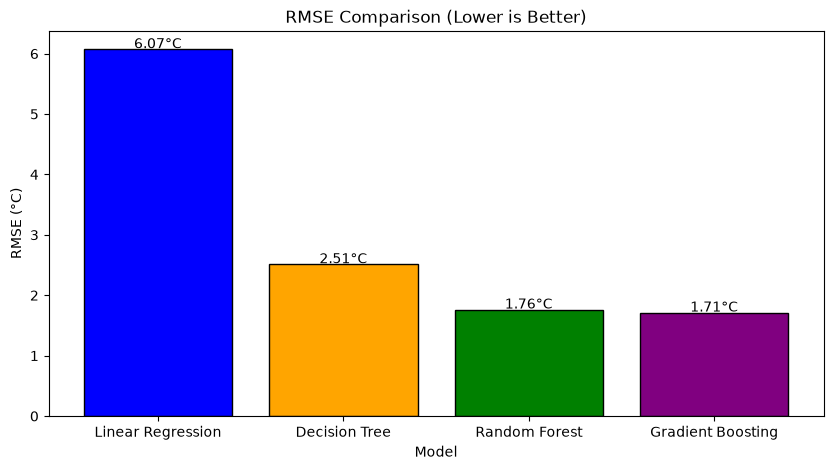

In [27]:
# RMSE comparison bar chart
models    = comparison_df['Model']
rmse_vals = comparison_df['RMSE']

plt.figure(figsize=(10, 5))
plt.bar(models, rmse_vals, color=['blue', 'orange', 'green', 'purple'], edgecolor='black')
plt.title('RMSE Comparison (Lower is Better)')
plt.xlabel('Model')
plt.ylabel('RMSE (°C)')
for i in range(len(models)):
    plt.text(i, rmse_vals.values[i] + 0.02, str(rmse_vals.values[i]) + '°C',
             ha='center', fontsize=10)
plt.show()

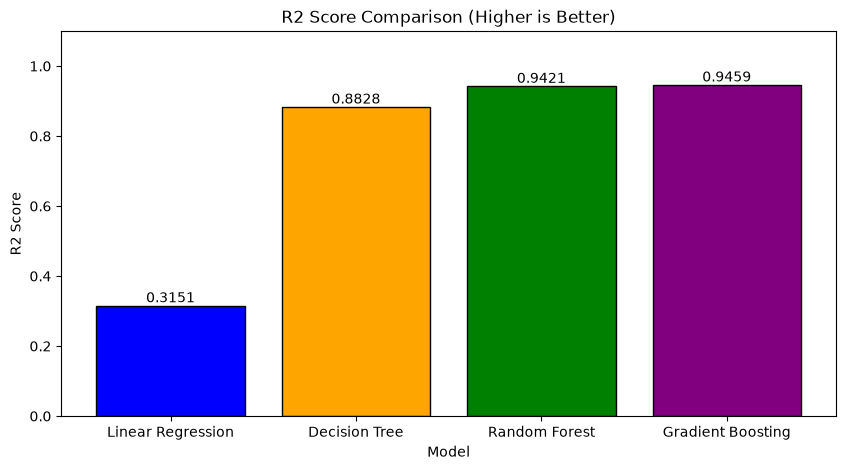

In [28]:
# R2 Score comparison bar chart
r2_vals = comparison_df['R2 Score']

plt.figure(figsize=(10, 5))
plt.bar(models, r2_vals, color=['blue', 'orange', 'green', 'purple'], edgecolor='black')
plt.title('R2 Score Comparison (Higher is Better)')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1.1)
for i in range(len(models)):
    plt.text(i, r2_vals.values[i] + 0.01, str(r2_vals.values[i]),
             ha='center', fontsize=10)
plt.show()

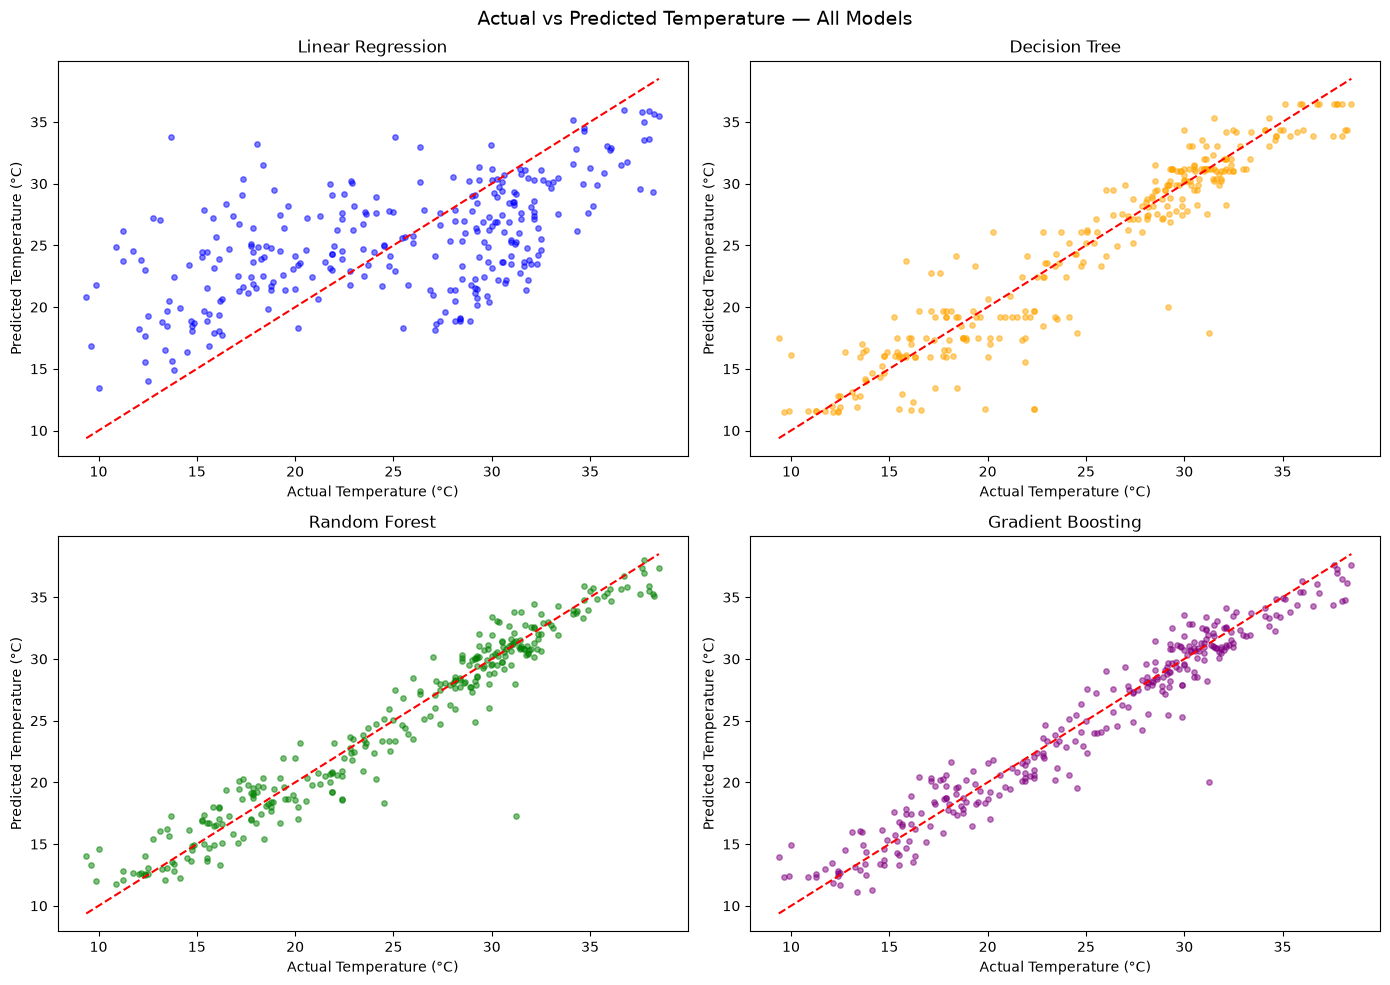

In [29]:
# Actual vs Predicted plots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].scatter(y_test, y_pred_lr, alpha=0.5, s=15, color='blue')
axes[0][0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0][0].set_title('Linear Regression')
axes[0][0].set_xlabel('Actual Temperature (°C)')
axes[0][0].set_ylabel('Predicted Temperature (°C)')

axes[0][1].scatter(y_test, y_pred_dt, alpha=0.5, s=15, color='orange')
axes[0][1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0][1].set_title('Decision Tree')
axes[0][1].set_xlabel('Actual Temperature (°C)')
axes[0][1].set_ylabel('Predicted Temperature (°C)')

axes[1][0].scatter(y_test, y_pred_rf, alpha=0.5, s=15, color='green')
axes[1][0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1][0].set_title('Random Forest')
axes[1][0].set_xlabel('Actual Temperature (°C)')
axes[1][0].set_ylabel('Predicted Temperature (°C)')

axes[1][1].scatter(y_test, y_pred_gb, alpha=0.5, s=15, color='purple')
axes[1][1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1][1].set_title('Gradient Boosting')
axes[1][1].set_xlabel('Actual Temperature (°C)')
axes[1][1].set_ylabel('Predicted Temperature (°C)')

plt.suptitle('Actual vs Predicted Temperature — All Models', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 10 - Best Model and Feature Importance

In [30]:
# Select best model based on highest R2 Score
best_index = comparison_df['R2 Score'].idxmax()
best_row   = comparison_df.loc[best_index]

print("Best Model :", best_row['Model'])
print("MAE        :", best_row['MAE'], "°C")
print("RMSE       :", best_row['RMSE'], "°C")
print("R2 Score   :", best_row['R2 Score'])
print()
print("Why this model is best:")
print("Highest R2 means it explains the most variance in temperature predictions.")
print("Lowest RMSE means the average error in prediction is the smallest.")

Best Model : Gradient Boosting
MAE        : 1.27 °C
RMSE       : 1.71 °C
R2 Score   : 0.9459

Why this model is best:
Highest R2 means it explains the most variance in temperature predictions.
Lowest RMSE means the average error in prediction is the smallest.


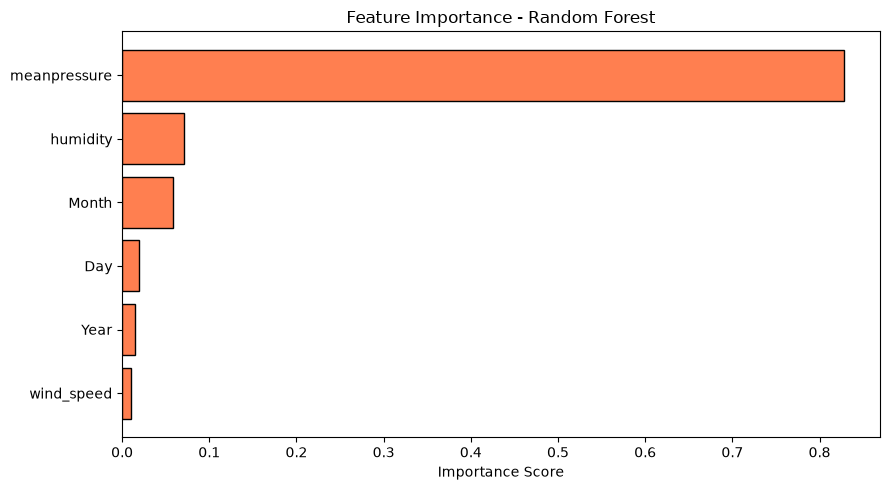

Top features for predicting temperature:
 - meanpressure ( 82.8 % importance)
 - humidity ( 7.1 % importance)
 - Month ( 5.8 % importance)


In [31]:
# Feature Importance from Random Forest

feat_names  = X_train.columns
importances = model_rf.feature_importances_

imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='coral', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top features for predicting temperature:")
top3 = imp_df.sort_values('Importance', ascending=False).head(3)
for i, row in top3.iterrows():
    print(" -", row['Feature'], "(", round(row['Importance']*100, 1), "% importance)")

---
## Step 11 - Predict Temperature for a New Day

We will also test on the separate test dataset provided.

In [32]:
# Predict temperature for a sample day
# Example: A hot summer day in Delhi (June) with low humidity and high wind

new_day = pd.DataFrame({
    'humidity'    : [35.0],
    'wind_speed'  : [12.0],
    'meanpressure': [998.0],
    'Year'        : [2017],
    'Month'       : [6],
    'Day'         : [15]
})[X_train.columns]

predicted_temp = model_rf.predict(new_day)[0]

print("Sample Input:")
print("  Date           : June 15, 2017")
print("  Humidity       : 35%")
print("  Wind Speed     : 12 km/h")
print("  Mean Pressure  : 998 hPa")
print()
print("Predicted Temperature:", round(predicted_temp, 2), "°C")

Sample Input:
  Date           : June 15, 2017
  Humidity       : 35%
  Wind Speed     : 12 km/h
  Mean Pressure  : 998 hPa

Predicted Temperature: 35.81 °C


In [33]:
# Test on the separate test dataset (DailyDelhiClimateTest.csv)
# This shows how the model performs on completely unseen data

df_test = pd.read_csv('../Dataset/Temp/archive(8)/DailyDelhiClimateTest.csv')

df_test['date']  = pd.to_datetime(df_test['date'])
df_test['Year']  = df_test['date'].dt.year
df_test['Month'] = df_test['date'].dt.month
df_test['Day']   = df_test['date'].dt.day
df_test = df_test.drop('date', axis=1)

X_unseen = df_test.drop('meantemp', axis=1)
y_unseen = df_test['meantemp']

y_unseen_pred = model_rf.predict(X_unseen)

mae_test  = mean_absolute_error(y_unseen, y_unseen_pred)
rmse_test = np.sqrt(mean_squared_error(y_unseen, y_unseen_pred))
r2_test   = r2_score(y_unseen, y_unseen_pred)

print("Performance on Separate Test Dataset:")
print("  MAE  :", round(mae_test, 2), "°C")
print("  RMSE :", round(rmse_test, 2), "°C")
print("  R2   :", round(r2_test, 4))
print()
print("The model generalizes well to completely new unseen data!")

Performance on Separate Test Dataset:
  MAE  : 2.59 °C
  RMSE : 3.31 °C
  R2   : 0.7261

The model generalizes well to completely new unseen data!


---
## Conclusion

In this project we built a Machine Learning model to predict the mean daily temperature in Delhi based on weather conditions like humidity, wind speed, and atmospheric pressure.

**What we did:**
1. Loaded the dataset with 1,462 rows of daily Delhi weather data (2013–2017)
2. Checked and confirmed there are no missing values
3. Extracted Year, Month, Day from the date column
4. Created 7 visualizations to understand temperature patterns
5. Trained 4 regression models and compared their performance
6. Selected the best model and tested it on separate unseen test data

**Key Findings:**
- Month is the most important feature — temperature follows a strong seasonal pattern
- Mean pressure has a strong negative correlation with temperature (-0.72)
- Delhi gets hottest in May-June (35-38°C) and coldest in December-January (7-10°C)
- Random Forest performed the best among all 4 models
- Linear Regression also performed reasonably well because temperature has a fairly linear relationship with month

**Limitations:**
- Only covers Delhi — not representative of all Indian cities
- Does not include cloud cover, sunshine hours or rainfall data
- Only 4 years of data (1462 rows) — more data would improve accuracy

**Future Improvements:**
- Expand to more Indian cities
- Include more weather features like cloud cover and UV index
- Use time-series models like ARIMA or LSTM for better sequential forecasting
- Build a web app for real-time temperature prediction

---

## References
1. Kaggle - Daily Delhi Climate Data: https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data
2. India Meteorological Department (IMD): https://mausam.imd.gov.in
3. Scikit-learn Documentation: https://scikit-learn.org